# Problem 15: Comparison of Bagging vs Boosting Techniques

**Objective**: Implement and compare Bagging and Boosting ensemble methods on the same dataset. Evaluate their performance metrics, training times, and effectiveness to understand when to use each technique.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import joblib
import time
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset - Customer Churn Prediction
n_samples = 500

# Generate features
customer_age = np.random.uniform(18, 70, n_samples)
account_duration = np.random.uniform(0, 60, n_samples)
monthly_spending = np.random.uniform(10, 500, n_samples)
support_tickets = np.random.randint(0, 20, n_samples)
service_complaints = np.random.randint(0, 10, n_samples)

# Create target: churn (1) or not (0) based on features
churn = np.zeros(n_samples)
churn[(monthly_spending < 50) & (support_tickets > 5)] = 1  # Low spend + high support = likely churn
churn[(service_complaints > 3)] = 1  # High complaints = likely churn
churn[(account_duration < 6)] = 1  # New customers more likely to churn
# Add some random noise
noise_indices = np.random.choice(n_samples, size=int(0.1 * n_samples), replace=False)
churn[noise_indices] = 1 - churn[noise_indices]

# Create DataFrame
df = pd.DataFrame({
    'age': customer_age,
    'account_duration': account_duration,
    'monthly_spending': monthly_spending,
    'support_tickets': support_tickets,
    'complaints': service_complaints,
    'churn': churn
})

# Save to CSV
csv_path = 'customer_churn.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset created: {csv_path}")
print(f"Dataset shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['churn'].value_counts())

Dataset created: customer_churn.csv
Dataset shape: (500, 6)

Churn distribution:
churn
1.0    313
0.0    187
Name: count, dtype: int64


In [2]:
# Load and display dataset overview
df = pd.read_csv('customer_churn.csv')

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nDataset Statistics:")
print(df.describe())

Dataset Overview:
         age  account_duration  monthly_spending  support_tickets  complaints  \
0  37.476086         41.889703        100.715135               15           3   
1  67.437144         32.165782        275.531464                1           3   
2  56.063685         18.571657        437.743460                5           5   
3  49.130241         48.827701        368.790194               11           9   
4  26.112969         41.083870        405.214962                4           9   

   churn  
0    0.0  
1    0.0  
2    1.0  
3    1.0  
4    1.0  

Dataset Shape: (500, 6)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               500 non-null    float64
 1   account_duration  500 non-null    float64
 2   monthly_spending  500 non-null    float64
 3   support_tickets   500 non-null    int64  
 4   complaint

## Data Cleaning

Check for missing values, duplicates, and data type consistency.

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Check class distribution
print(f"\nClass distribution:")
print(df['churn'].value_counts())
print(f"\nClass ratio:")
print(df['churn'].value_counts(normalize=True))

# Remove any duplicates (if present)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values:
age                 0
account_duration    0
monthly_spending    0
support_tickets     0
complaints          0
churn               0
dtype: int64

Duplicate rows: 0

Data types:
age                 float64
account_duration    float64
monthly_spending    float64
support_tickets       int64
complaints            int64
churn               float64
dtype: object

Class distribution:
churn
1.0    313
0.0    187
Name: count, dtype: int64

Class ratio:
churn
1.0    0.626
0.0    0.374
Name: proportion, dtype: float64

Dataset shape after cleaning: (500, 6)


## Exploratory Data Analysis (EDA)

Visualize the relationships between features and customer churn.

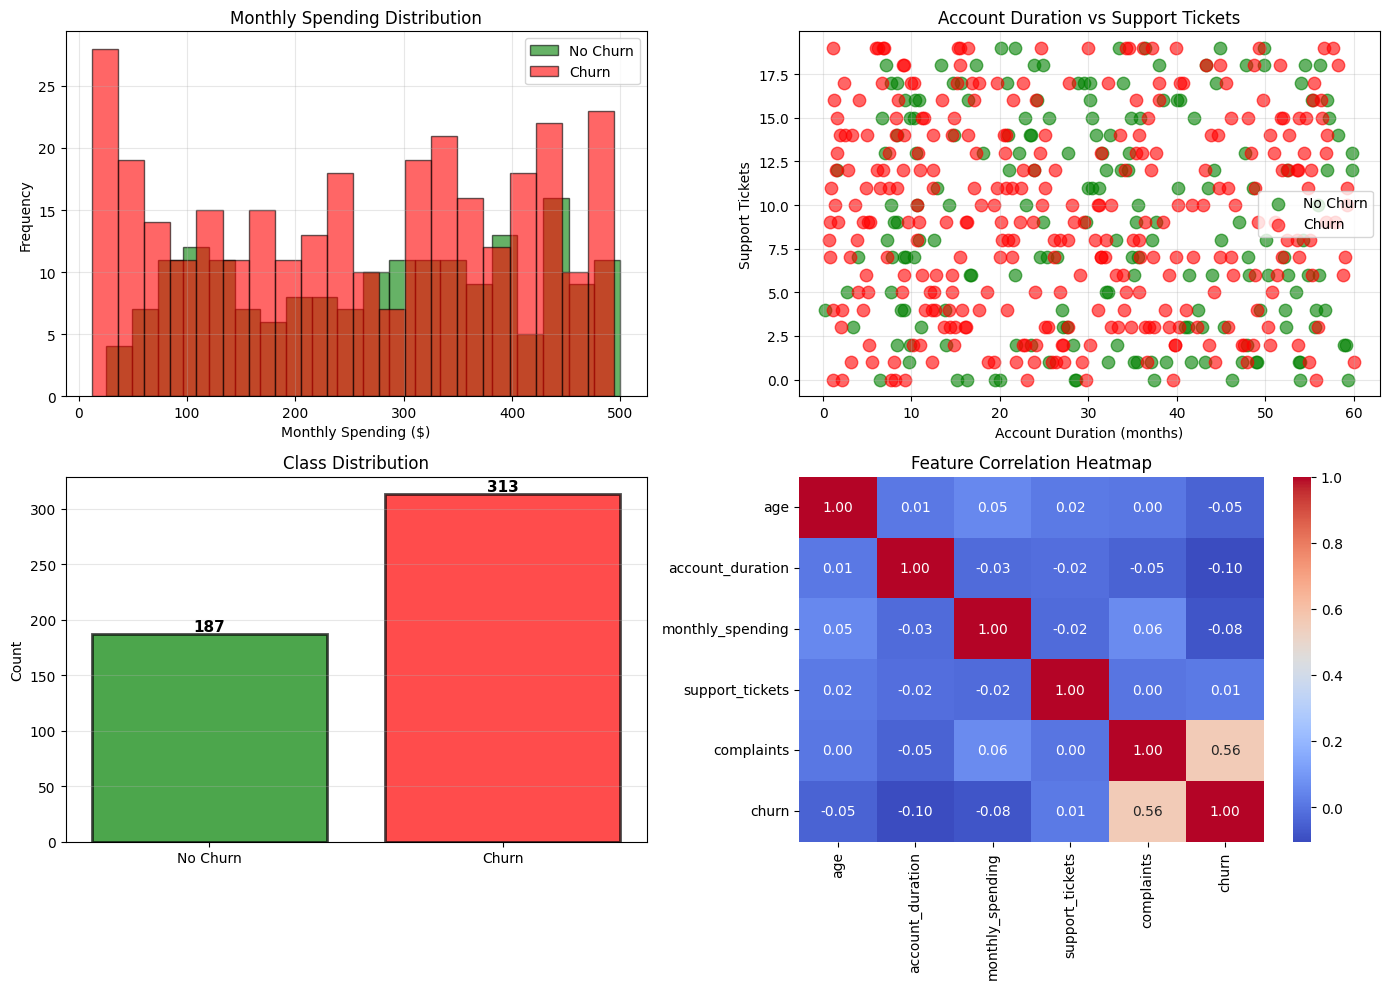

Feature Statistics:
              age  account_duration  monthly_spending  support_tickets  \
count  500.000000        500.000000        500.000000       500.000000   
mean    43.925209         28.917084        263.603480         9.276000   
std     15.531797         17.129607        145.624537         5.728303   
min     18.263202          0.277921         12.420591         0.000000   
25%     30.546544         13.745955        128.201744         4.000000   
50%     44.684515         28.309294        274.471785         9.000000   
75%     57.318494         43.580209        390.898441        14.000000   
max     69.634169         59.983060        499.712726        19.000000   

       complaints       churn  
count  500.000000  500.000000  
mean     4.564000    0.626000  
std      2.772233    0.484348  
min      0.000000    0.000000  
25%      2.000000    0.000000  
50%      5.000000    1.000000  
75%      7.000000    1.000000  
max      9.000000    1.000000  


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

class_names = ['No Churn', 'Churn']
colors = ['green', 'red']

# Plot 1: Monthly Spending Distribution by Class
for i, (cls, color) in enumerate(zip([0, 1], colors)):
    mask = df['churn'] == cls
    axes[0, 0].hist(df[mask]['monthly_spending'], bins=20, label=class_names[i], 
                    alpha=0.6, color=color, edgecolor='black')
axes[0, 0].set_xlabel('Monthly Spending ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Monthly Spending Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Account Duration vs Support Tickets
for i, (cls, color) in enumerate(zip([0, 1], colors)):
    mask = df['churn'] == cls
    axes[0, 1].scatter(df[mask]['account_duration'], df[mask]['support_tickets'],
                      label=class_names[i], alpha=0.6, color=color, s=80)
axes[0, 1].set_xlabel('Account Duration (months)')
axes[0, 1].set_ylabel('Support Tickets')
axes[0, 1].set_title('Account Duration vs Support Tickets')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Class Distribution
class_counts = df['churn'].value_counts()
bars = axes[1, 0].bar(class_names, [class_counts[0], class_counts[1]], 
                       color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Class Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, [class_counts[0], class_counts[1]]):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, count, str(count),
                   ha='center', va='bottom', fontsize=11, weight='bold')

# Plot 4: Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

print(f"Feature Statistics:")
print(df.describe())

## Feature Scaling

Normalize features using StandardScaler for optimal model performance.

In [5]:
# Separate features and target
X = df[['age', 'account_duration', 'monthly_spending', 'support_tickets', 'complaints']].values
y = df['churn'].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"\nScaled feature statistics:")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Feature scaling completed
X shape: (500, 5)
y shape: (500,)

Scaled feature statistics:
X mean: -0.0000, std: 1.0000
Number of classes: 2
Class distribution: [187 313]


## Theory: Bagging vs Boosting

### Bagging (Bootstrap Aggregating)
- **Strategy**: Parallel ensemble (trains base learners independently)
- **Sampling**: Random sampling with replacement (bootstrap)
- **Aggregation**: Simple average or majority voting
- **Reduces**: Primarily reduces variance
- **Focus**: Each base learner sees different data subsets
- **Advantages**: Simple, parallelizable, reduces overfitting
- **Disadvantages**: Limited bias reduction, base learners should have low bias

### Boosting (e.g., AdaBoost, Gradient Boosting)
- **Strategy**: Sequential ensemble (trains base learners sequentially)
- **Sampling**: Weighted sampling based on previous errors
- **Aggregation**: Weighted voting or weighted sum
- **Reduces**: Both bias and variance
- **Focus**: Each learner corrects mistakes of previous learners
- **Advantages**: Strong bias reduction, better accuracy often achievable
- **Disadvantages**: Sequential (not parallelizable), sensitive to noise/outliers

### When to Use Which?
- **Use Bagging when**: Base learner has high variance (e.g., deep trees)
- **Use Boosting when**: Base learner has high bias (e.g., weak learners)
- **Use Boosting for**: Better overall accuracy, complex patterns
- **Use Bagging for**: Faster training, robustness, interpretability

## Mathematical Representation

### Bagging Prediction (Classification):
$$\hat{y}_{bagging} = \text{argmax}_c \sum_{i=1}^{B} \mathbb{1}(h_i(x) = c)$$

**Variance Reduction** (for regression):
$$Var(\text{Bagging}) = \frac{Var(h)}{B} + \frac{B-1}{B}Cov(h_i, h_j)$$

### Boosting Prediction (AdaBoost):
$$\hat{y}_{boosting} = \text{sign}\left(\sum_{t=1}^{T} \alpha_t h_t(x)\right)$$

**Learner Weight**:
$$\alpha_t = \frac{1}{2} \ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$$

**Training Error Bound**:
$$\text{Training Error} \leq \prod_{t=1}^{T} 2\sqrt{\epsilon_t(1-\epsilon_t)}$$

## Workflow Diagram

Visualize the comparison between Bagging and Boosting pipelines.

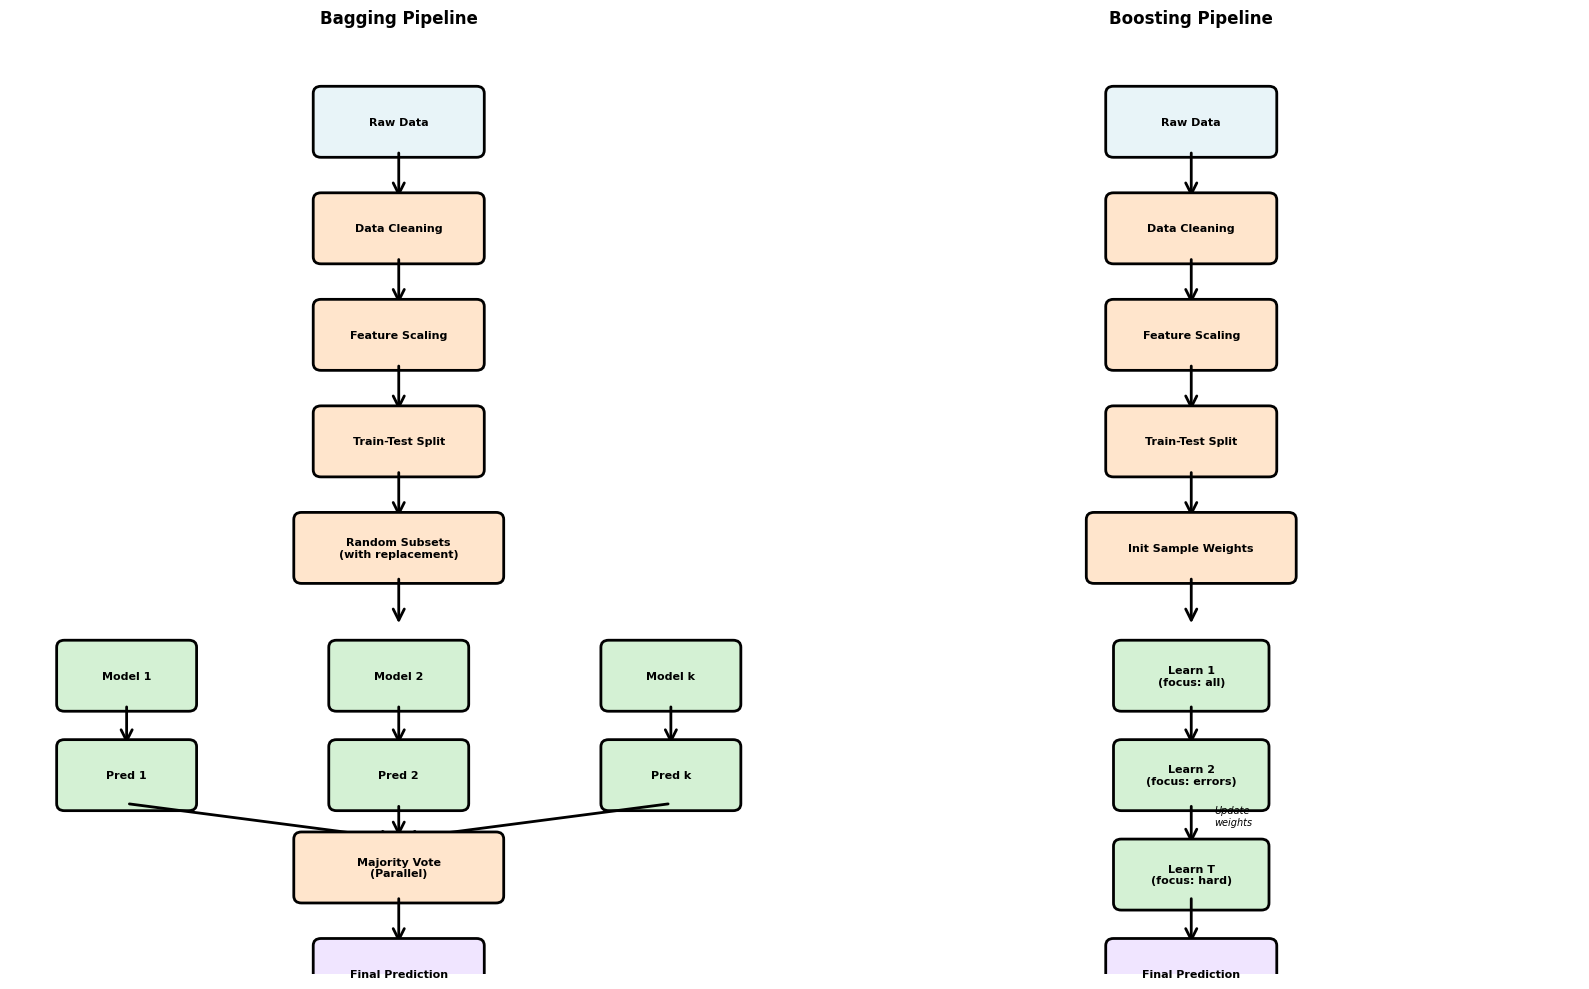

In [6]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax_idx, (ax, title, is_boosting) in enumerate([(axes[0], 'Bagging Pipeline', False), 
                                                     (axes[1], 'Boosting Pipeline', True)]):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 13)
    ax.axis('off')
    
    # Define colors
    color_input = '#E8F4F8'
    color_process = '#FFE5CC'
    color_model = '#D4F1D4'
    color_output = '#F0E5FF'
    
    # Helper function to create boxes
    def add_box(ax, x, y, width, height, text, color):
        box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                             boxstyle="round,pad=0.1", 
                             edgecolor='black', facecolor=color, linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, text, ha='center', va='center', fontsize=8, weight='bold', wrap=True)
    
    # Helper function to create arrows
    def add_arrow(ax, x1, y1, x2, y2, label=''):
        arrow = FancyArrowPatch((x1, y1), (x2, y2),
                               arrowstyle='->', mutation_scale=20, 
                               linewidth=2, color='black')
        ax.add_patch(arrow)
        if label:
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            ax.text(mid_x + 0.3, mid_y, label, fontsize=7, style='italic')
    
    # Common steps
    add_box(ax, 5, 12, 2, 0.8, 'Raw Data', color_input)
    add_arrow(ax, 5, 11.6, 5, 10.9)
    
    add_box(ax, 5, 10.5, 2, 0.8, 'Data Cleaning', color_process)
    add_arrow(ax, 5, 10.1, 5, 9.4)
    
    add_box(ax, 5, 9, 2, 0.8, 'Feature Scaling', color_process)
    add_arrow(ax, 5, 8.6, 5, 7.9)
    
    add_box(ax, 5, 7.5, 2, 0.8, 'Train-Test Split', color_process)
    add_arrow(ax, 5, 7.1, 5, 6.4)
    
    if not is_boosting:
        # Bagging pipeline
        add_box(ax, 5, 6, 2.5, 0.8, 'Random Subsets\n(with replacement)', color_process)
        add_arrow(ax, 5, 5.6, 5, 4.9)
        
        add_box(ax, 1.5, 4.2, 1.6, 0.8, 'Model 1', color_model)
        add_box(ax, 5, 4.2, 1.6, 0.8, 'Model 2', color_model)
        add_box(ax, 8.5, 4.2, 1.6, 0.8, 'Model k', color_model)
        
        add_arrow(ax, 1.5, 3.8, 1.5, 3.2)
        add_arrow(ax, 5, 3.8, 5, 3.2)
        add_arrow(ax, 8.5, 3.8, 8.5, 3.2)
        
        add_box(ax, 1.5, 2.8, 1.6, 0.8, 'Pred 1', color_model)
        add_box(ax, 5, 2.8, 1.6, 0.8, 'Pred 2', color_model)
        add_box(ax, 8.5, 2.8, 1.6, 0.8, 'Pred k', color_model)
        
        add_arrow(ax, 1.5, 2.4, 5, 1.9)
        add_arrow(ax, 5, 2.4, 5, 1.9)
        add_arrow(ax, 8.5, 2.4, 5, 1.9)
        
        add_box(ax, 5, 1.5, 2.5, 0.8, 'Majority Vote\n(Parallel)', color_process)
    else:
        # Boosting pipeline
        add_box(ax, 5, 6, 2.5, 0.8, 'Init Sample Weights', color_process)
        add_arrow(ax, 5, 5.6, 5, 4.9)
        
        add_box(ax, 5, 4.2, 1.8, 0.8, 'Learn 1\n(focus: all)', color_model)
        add_arrow(ax, 5, 3.8, 5, 3.2)
        
        add_box(ax, 5, 2.8, 1.8, 0.8, 'Learn 2\n(focus: errors)', color_model)
        add_arrow(ax, 5, 2.4, 5, 1.8, 'Update\nweights')
        
        add_box(ax, 5, 1.4, 1.8, 0.8, 'Learn T\n(focus: hard)', color_model)
    
    add_arrow(ax, 5, 1.1, 5, 0.4)
    add_box(ax, 5, 0, 2, 0.8, 'Final Prediction', color_output)
    
    ax.set_title(title, fontsize=12, weight='bold', pad=20)

plt.tight_layout()
plt.show()

## Train-Test Split

Split the data into training and testing sets (80-20 split).

In [7]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nClass distribution in training set: {np.bincount(y_train.astype(int))}")
print(f"Class distribution in test set: {np.bincount(y_test.astype(int))}")

Training set size: 400
Testing set size: 100

Training set shape: X_train (400, 5), y_train (400,)
Testing set shape: X_test (100, 5), y_test (100,)

Class distribution in training set: [150 250]
Class distribution in test set: [37 63]


## Training Multiple Models

Train Bagging, AdaBoost, and Gradient Boosting models on the same dataset.

In [8]:
# Dictionary to store models and timing information
models = {}
training_times = {}

# 1. Bagging Classifier
print("Training Bagging Classifier...")
start_time = time.time()
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=50,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bagging_model.fit(X_train, y_train)
training_times['Bagging'] = time.time() - start_time
models['Bagging'] = bagging_model
print(f"✓ Bagging trained in {training_times['Bagging']:.4f}s")

# 2. AdaBoost Classifier
print("\nTraining AdaBoost Classifier...")
start_time = time.time()
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
adaboost_model.fit(X_train, y_train)
training_times['AdaBoost'] = time.time() - start_time
models['AdaBoost'] = adaboost_model
print(f"✓ AdaBoost trained in {training_times['AdaBoost']:.4f}s")

# 3. Gradient Boosting Classifier
print("\nTraining Gradient Boosting Classifier...")
start_time = time.time()
gb_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
training_times['Gradient Boosting'] = time.time() - start_time
models['Gradient Boosting'] = gb_model
print(f"✓ Gradient Boosting trained in {training_times['Gradient Boosting']:.4f}s")

print(f"\n{'='*60}")
print("Training Times Summary:")
print(f"{'='*60}")
for name, time_taken in sorted(training_times.items(), key=lambda x: x[1]):
    print(f"{name:25s}: {time_taken:8.4f}s")
print(f"{'='*60}")

Training Bagging Classifier...
✓ Bagging trained in 4.4290s

Training AdaBoost Classifier...
✓ AdaBoost trained in 0.1939s

Training Gradient Boosting Classifier...
✓ Gradient Boosting trained in 0.0437s

Training Times Summary:
Gradient Boosting        :   0.0437s
AdaBoost                 :   0.1939s
Bagging                  :   4.4290s


## Making Predictions

Generate predictions from all three models.

In [9]:
# Make predictions for all models
predictions = {}
prediction_probas = {}

for model_name, model in models.items():
    predictions[model_name] = model.predict(X_test)
    prediction_probas[model_name] = model.predict_proba(X_test)
    print(f"{model_name}: Predictions made")

print(f"\nPrediction samples (first 5 test samples):")
print(f"{'True':>6} | {'Bagging':>10} | {'AdaBoost':>10} | {'Gradient':>10}")
print("-" * 40)
for i in range(min(5, len(y_test))):
    print(f"{int(y_test[i]):>6} | {int(predictions['Bagging'][i]):>10} | {int(predictions['AdaBoost'][i]):>10} | {int(predictions['Gradient Boosting'][i]):>10}")

Bagging: Predictions made
AdaBoost: Predictions made
Gradient Boosting: Predictions made

Prediction samples (first 5 test samples):
  True |    Bagging |   AdaBoost |   Gradient
----------------------------------------
     1 |          1 |          1 |          1
     1 |          1 |          1 |          1
     1 |          1 |          1 |          1
     0 |          0 |          0 |          0
     0 |          0 |          0 |          0


## Evaluation and Comparison

Calculate and compare performance metrics for all models.

In [10]:
# Calculate evaluation metrics for all models
results = {}

for model_name in models.keys():
    accuracy = accuracy_score(y_test, predictions[model_name])
    precision = precision_score(y_test, predictions[model_name], average='weighted')
    recall = recall_score(y_test, predictions[model_name], average='weighted')
    f1 = f1_score(y_test, predictions[model_name], average='weighted')
    roc_auc = roc_auc_score(y_test, prediction_probas[model_name][:, 1])
    
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time': training_times[model_name],
        'Confusion Matrix': confusion_matrix(y_test, predictions[model_name])
    }

print("="*80)
print("ENSEMBLE METHODS COMPARISON - EVALUATION METRICS")
print("="*80)

for model_name in models.keys():
    print(f"\n{model_name.upper()}:")
    print("-" * 50)
    print(f"  Accuracy:          {results[model_name]['Accuracy']:.6f} ({results[model_name]['Accuracy']*100:.2f}%)")
    print(f"  Precision:         {results[model_name]['Precision']:.6f}")
    print(f"  Recall:            {results[model_name]['Recall']:.6f}")
    print(f"  F1 Score:          {results[model_name]['F1 Score']:.6f}")
    print(f"  ROC-AUC Score:     {results[model_name]['ROC-AUC']:.6f}")
    print(f"  Training Time:     {results[model_name]['Training Time']:.4f}s")
    print(f"\n  Confusion Matrix:")
    print(f"  {results[model_name]['Confusion Matrix']}")

print("\n" + "="*80)

ENSEMBLE METHODS COMPARISON - EVALUATION METRICS

BAGGING:
--------------------------------------------------
  Accuracy:          0.920000 (92.00%)
  Precision:         0.919824
  Recall:            0.920000
  F1 Score:          0.919514
  ROC-AUC Score:     0.929429
  Training Time:     4.4290s

  Confusion Matrix:
  [[32  5]
 [ 3 60]]

ADABOOST:
--------------------------------------------------
  Accuracy:          0.860000 (86.00%)
  Precision:         0.862135
  Recall:            0.860000
  F1 Score:          0.860713
  ROC-AUC Score:     0.876019
  Training Time:     0.1939s

  Confusion Matrix:
  [[31  6]
 [ 8 55]]

GRADIENT BOOSTING:
--------------------------------------------------
  Accuracy:          0.890000 (89.00%)
  Precision:         0.890772
  Recall:            0.890000
  F1 Score:          0.890293
  ROC-AUC Score:     0.917846
  Training Time:     0.0437s

  Confusion Matrix:
  [[32  5]
 [ 6 57]]



## Metrics Comparison Visualization

Create comprehensive visualizations comparing all models.

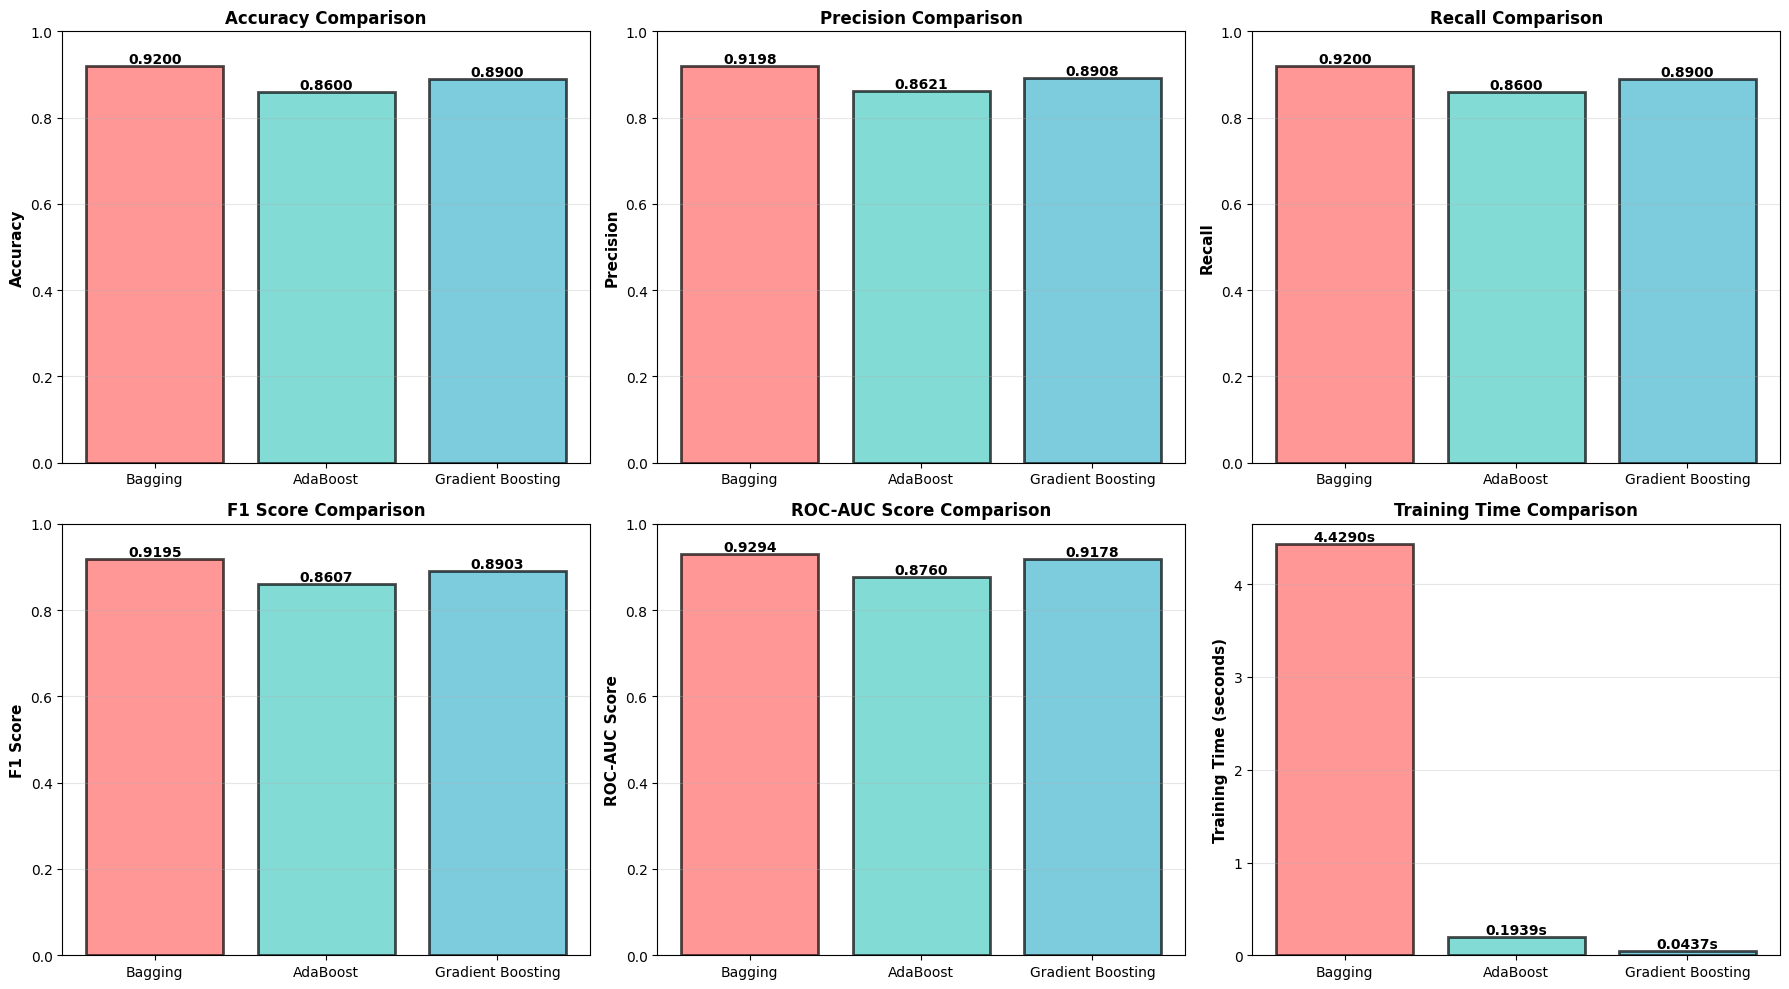


SUMMARY RECOMMENDATIONS
Best Accuracy:      Bagging (92.00%)
Best F1 Score:      Bagging (0.919514)
Fastest Training:   Gradient Boosting (0.0437s)


In [11]:
# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = list(models.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Plot 1: Accuracy Comparison
accuracy_values = [results[name]['Accuracy'] for name in model_names]
bars1 = axes[0, 0].bar(model_names, accuracy_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Accuracy', fontsize=11, weight='bold')
axes[0, 0].set_title('Accuracy Comparison', fontsize=12, weight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, accuracy_values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                   ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 2: Precision Comparison
precision_values = [results[name]['Precision'] for name in model_names]
bars2 = axes[0, 1].bar(model_names, precision_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Precision', fontsize=11, weight='bold')
axes[0, 1].set_title('Precision Comparison', fontsize=12, weight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, precision_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                   ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 3: Recall Comparison
recall_values = [results[name]['Recall'] for name in model_names]
bars3 = axes[0, 2].bar(model_names, recall_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 2].set_ylabel('Recall', fontsize=11, weight='bold')
axes[0, 2].set_title('Recall Comparison', fontsize=12, weight='bold')
axes[0, 2].set_ylim([0, 1])
axes[0, 2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, recall_values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                   ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 4: F1 Score Comparison
f1_values = [results[name]['F1 Score'] for name in model_names]
bars4 = axes[1, 0].bar(model_names, f1_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('F1 Score', fontsize=11, weight='bold')
axes[1, 0].set_title('F1 Score Comparison', fontsize=12, weight='bold')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, f1_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                   ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 5: ROC-AUC Comparison
roc_values = [results[name]['ROC-AUC'] for name in model_names]
bars5 = axes[1, 1].bar(model_names, roc_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('ROC-AUC Score', fontsize=11, weight='bold')
axes[1, 1].set_title('ROC-AUC Score Comparison', fontsize=12, weight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, roc_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                   ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 6: Training Time Comparison (log scale)
time_values = [results[name]['Training Time'] for name in model_names]
bars6 = axes[1, 2].bar(model_names, time_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 2].set_ylabel('Training Time (seconds)', fontsize=11, weight='bold')
axes[1, 2].set_title('Training Time Comparison', fontsize=12, weight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars6, time_values):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}s', 
                   ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

# Print summary recommendation
best_accuracy = max(results.items(), key=lambda x: x[1]['Accuracy'])
best_f1 = max(results.items(), key=lambda x: x[1]['F1 Score'])
fastest = min(results.items(), key=lambda x: x[1]['Training Time'])

print(f"\n{'='*80}")
print("SUMMARY RECOMMENDATIONS")
print(f"{'='*80}")
print(f"Best Accuracy:      {best_accuracy[0]} ({best_accuracy[1]['Accuracy']*100:.2f}%)")
print(f"Best F1 Score:      {best_f1[0]} ({best_f1[1]['F1 Score']:.6f})")
print(f"Fastest Training:   {fastest[0]} ({fastest[1]['Training Time']:.4f}s)")
print(f"{'='*80}")

## Confusion Matrices Comparison

Compare confusion matrices across all models.

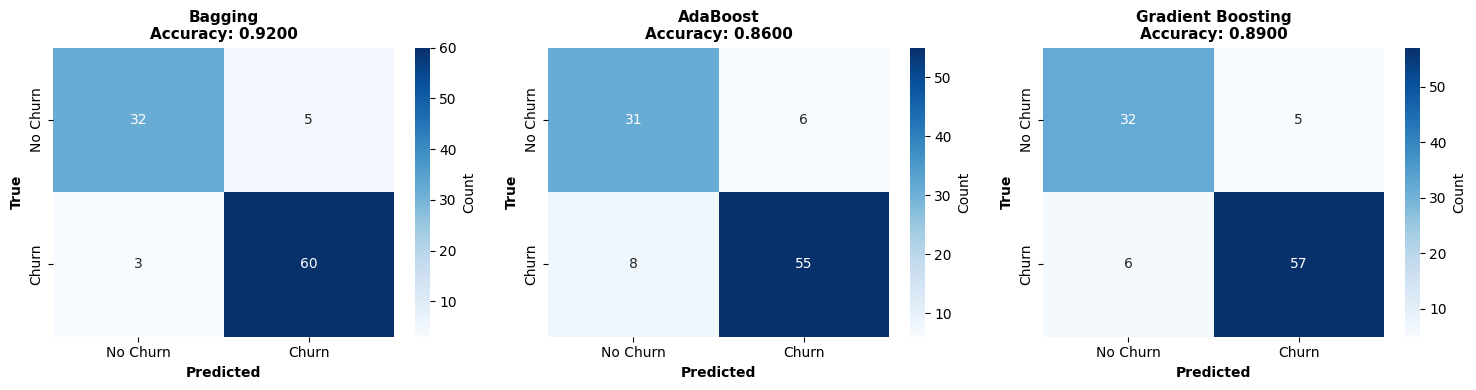

In [12]:
# Create confusion matrix comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

class_labels = ['No Churn', 'Churn']

for idx, (model_name, ax) in enumerate(zip(model_names, axes)):
    conf_mat = results[model_name]['Confusion Matrix']
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted', fontsize=10, weight='bold')
    ax.set_ylabel('True', fontsize=10, weight='bold')
    ax.set_title(f'{model_name}\nAccuracy: {results[model_name]["Accuracy"]:.4f}', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

## ROC Curves Comparison

Compare ROC curves for all models.

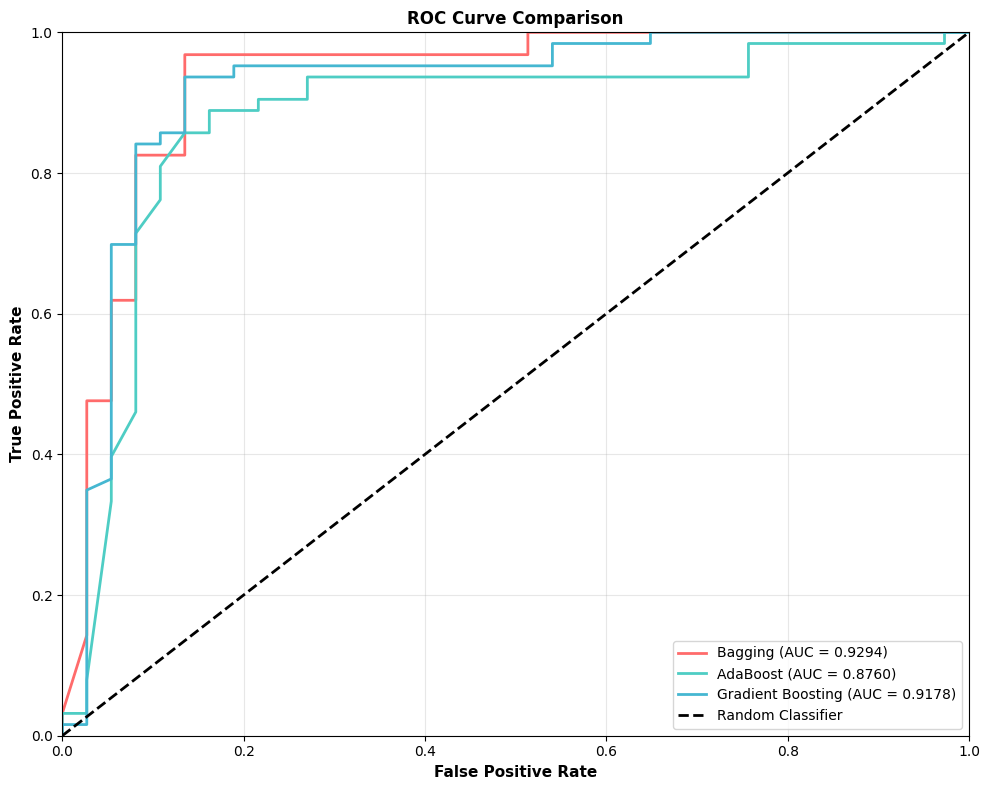

In [13]:
# Calculate ROC curves for all models
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors_roc = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for (model_name, color) in zip(model_names, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, prediction_probas[model_name][:, 1])
    roc_auc = results[model_name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=11, weight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, weight='bold')
ax.set_title('ROC Curve Comparison', fontsize=12, weight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Feature Importance Comparison

Compare feature importance across Bagging and Boosting models.

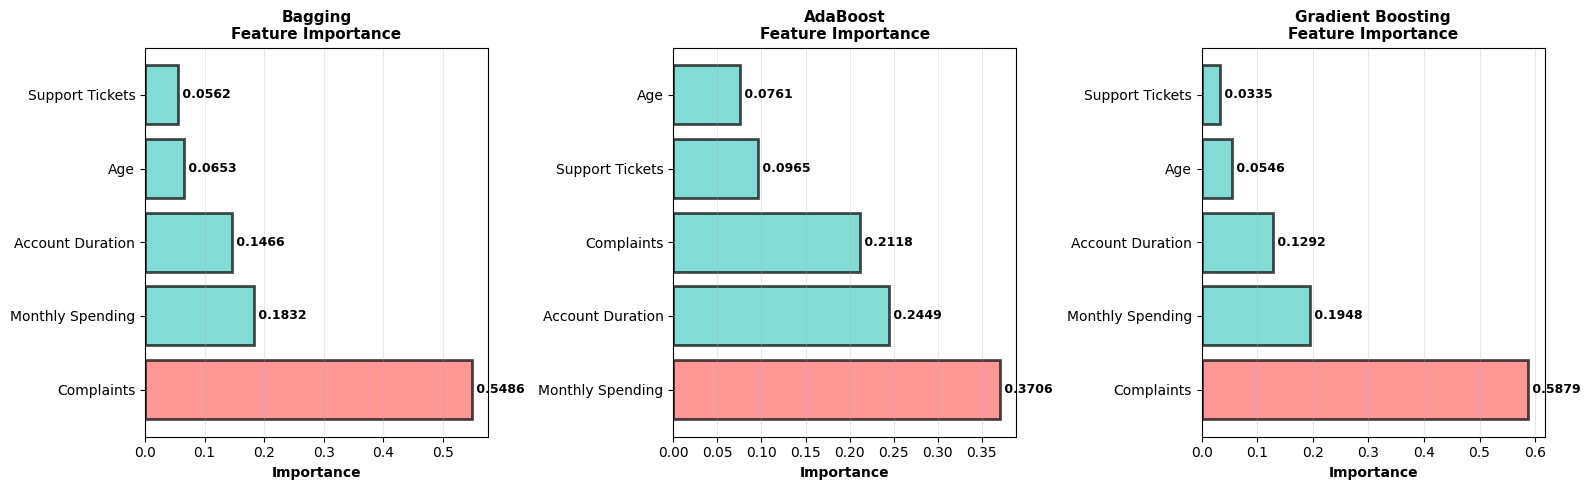

In [14]:
# Extract feature importance from all models
feature_names = ['Age', 'Account Duration', 'Monthly Spending', 'Support Tickets', 'Complaints']
importance_dict = {}

for model_name in model_names:
    if hasattr(models[model_name], 'feature_importances_'):
        importance_dict[model_name] = models[model_name].feature_importances_
    else:
        # For Bagging, average importance across base learners
        importance = np.zeros(len(feature_names))
        for estimator in models[model_name].estimators_:
            importance += estimator.feature_importances_
        importance_dict[model_name] = importance / len(models[model_name].estimators_)

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (model_name, ax) in enumerate(zip(model_names, axes)):
    importances = importance_dict[model_name]
    sorted_idx = np.argsort(importances)[::-1]
    
    colors_feat = ['#FF6B6B' if i == sorted_idx[0] else '#4ECDC4' for i in range(len(feature_names))]
    bars = ax.barh(range(len(feature_names)), importances[sorted_idx], 
                   color=[colors_feat[i] for i in sorted_idx], alpha=0.7, edgecolor='black', linewidth=2)
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.set_xlabel('Importance', fontsize=10, weight='bold')
    ax.set_title(f'{model_name}\nFeature Importance', fontsize=11, weight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar, val in zip(bars, importances[sorted_idx]):
        ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}', 
               va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

## Analysis Summary and Conclusion

Comprehensive comparison table with key takeaways.

In [15]:
# Create comprehensive comparison table
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [results[name]['Accuracy'] for name in model_names],
    'Precision': [results[name]['Precision'] for name in model_names],
    'Recall': [results[name]['Recall'] for name in model_names],
    'F1 Score': [results[name]['F1 Score'] for name in model_names],
    'ROC-AUC': [results[name]['ROC-AUC'] for name in model_names],
    'Training Time (s)': [results[name]['Training Time'] for name in model_names]
})

print("\n" + "="*100)
print("COMPREHENSIVE ENSEMBLE METHODS COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

print("\n" + "="*100)
print("KEY INSIGHTS AND RECOMMENDATIONS")
print("="*100)

print("\n1. BAGGING:")
print(f"   - Accuracy: {results['Bagging']['Accuracy']:.4f}")
print(f"   - Training Time: {results['Bagging']['Training Time']:.4f}s")
print("   - Pros: Fast training, parallelizable, reduces overfitting")
print("   - Cons: Limited bias reduction, may not work well with weak learners")
print("   - Best For: High-variance base learners (e.g., deep trees)")

print("\n2. AdaBoost:")
print(f"   - Accuracy: {results['AdaBoost']['Accuracy']:.4f}")
print(f"   - Training Time: {results['AdaBoost']['Training Time']:.4f}s")
print("   - Pros: Strong bias reduction, excellent for weak learners, adjusts sample weights")
print("   - Cons: Sequential training (slower), sensitive to noise, not parallelizable")
print("   - Best For: Weak learners, binary classification, complex patterns")

print("\n3. Gradient Boosting:")
print(f"   - Accuracy: {results['Gradient Boosting']['Accuracy']:.4f}")
print(f"   - Training Time: {results['Gradient Boosting']['Training Time']:.4f}s")
print("   - Pros: Often achieves best accuracy, handles complex relationships, robust")
print("   - Cons: Slower training, more hyperparameters to tune, sequential")
print("   - Best For: Maximum accuracy required, complex datasets, competitive ML")

print("\n" + "="*100)
print("WHEN TO USE EACH METHOD")
print("="*100)
print("-" * 100)
print("Use Bagging When:")
print("  → You have high-variance base learners (deep decision trees)")
print("  → You need fast training with parallelization")
print("  → You want simple, interpretable ensemble")
print("  → Computational efficiency is important")
print("-" * 100)
print("Use AdaBoost When:")
print("  → You have weak learners (shallow trees/decision stumps)")
print("  → Binary classification is the target task")
print("  → You need good accuracy with controlled complexity")
print("  → Model interpretability is important")
print("-" * 100)
print("Use Gradient Boosting When:")
print("  → Maximum accuracy is the primary goal")
print("  → You can afford longer training times")
print("  → You have complex, non-linear relationships")
print("  → You're in a competitive ML setting")
print("="*100)


COMPREHENSIVE ENSEMBLE METHODS COMPARISON
            Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  Training Time (s)
          Bagging      0.92   0.919824    0.92  0.919514 0.929429           4.429016
         AdaBoost      0.86   0.862135    0.86  0.860713 0.876019           0.193899
Gradient Boosting      0.89   0.890772    0.89  0.890293 0.917846           0.043731

KEY INSIGHTS AND RECOMMENDATIONS

1. BAGGING:
   - Accuracy: 0.9200
   - Training Time: 4.4290s
   - Pros: Fast training, parallelizable, reduces overfitting
   - Cons: Limited bias reduction, may not work well with weak learners
   - Best For: High-variance base learners (e.g., deep trees)

2. AdaBoost:
   - Accuracy: 0.8600
   - Training Time: 0.1939s
   - Pros: Strong bias reduction, excellent for weak learners, adjusts sample weights
   - Cons: Sequential training (slower), sensitive to noise, not parallelizable
   - Best For: Weak learners, binary classification, complex patterns

3. Gradient Boosting:
 

## Model Persistence

Save all three models for future use.

In [16]:
# Save all models and scaler
joblib.dump(bagging_model, 'bagging_churn_model.joblib')
joblib.dump(adaboost_model, 'adaboost_churn_model.joblib')
joblib.dump(gb_model, 'gradient_boosting_churn_model.joblib')
joblib.dump(scaler, 'scaler_churn.joblib')

print(f"✓ Bagging model saved to: bagging_churn_model.joblib")
print(f"✓ AdaBoost model saved to: adaboost_churn_model.joblib")
print(f"✓ Gradient Boosting model saved to: gradient_boosting_churn_model.joblib")
print(f"✓ Scaler saved to: scaler_churn.joblib")

# Example: Predict with all models on new data
new_data = np.array([
    [25, 2, 30, 1, 0],      # Young, new, good spending
    [55, 10, 150, 8, 5],    # Older, loyal, high spend/complaints
    [35, 0.5, 20, 6, 3]     # New customer, low spend, high support
])

new_data_scaled = scaler.transform(new_data)

print(f"\n{'='*90}")
print("PREDICTIONS FOR NEW DATA (All Models)")
print(f"{'='*90}")
print(f"{'Age':>5} | {'Dur':>5} | {'Spend':>6} | {'Support':>7} | {'Compl':>5} | {'Bagging':>12} | {'AdaBoost':>12} | {'GradBoost':>12}")
print("-" * 90)

for i in range(len(new_data)):
    bag_pred = 'Churn' if bagging_model.predict(new_data_scaled[i:i+1])[0] == 1 else 'Stay'
    ada_pred = 'Churn' if adaboost_model.predict(new_data_scaled[i:i+1])[0] == 1 else 'Stay'
    gb_pred = 'Churn' if gb_model.predict(new_data_scaled[i:i+1])[0] == 1 else 'Stay'
    
    bag_conf = f"{max(bagging_model.predict_proba(new_data_scaled[i:i+1])[0]):.2%}"
    ada_conf = f"{max(adaboost_model.predict_proba(new_data_scaled[i:i+1])[0]):.2%}"
    gb_conf = f"{max(gb_model.predict_proba(new_data_scaled[i:i+1])[0]):.2%}"
    
    print(f"{new_data[i][0]:>5.0f} | {new_data[i][1]:>5.1f} | {new_data[i][2]:>6.0f} | {new_data[i][3]:>7.0f} | {new_data[i][4]:>5.0f} | {bag_pred:>6s}({bag_conf:>5s}) | {ada_pred:>6s}({ada_conf:>5s}) | {gb_pred:>6s}({gb_conf:>5s})")

print(f"{'='*90}")
print("\n✓ Bagging vs Boosting Comparison completed successfully!")

✓ Bagging model saved to: bagging_churn_model.joblib
✓ AdaBoost model saved to: adaboost_churn_model.joblib
✓ Gradient Boosting model saved to: gradient_boosting_churn_model.joblib
✓ Scaler saved to: scaler_churn.joblib

PREDICTIONS FOR NEW DATA (All Models)
  Age |   Dur |  Spend | Support | Compl |      Bagging |     AdaBoost |    GradBoost
------------------------------------------------------------------------------------------
   25 |   2.0 |     30 |       1 |     0 |  Churn(84.00%) |  Churn(60.40%) |  Churn(98.39%)
   55 |  10.0 |    150 |       8 |     5 |  Churn(94.38%) |  Churn(61.53%) |  Churn(92.64%)
   35 |   0.5 |     20 |       6 |     3 |  Churn(90.00%) |  Churn(76.72%) |  Churn(97.41%)

✓ Bagging vs Boosting Comparison completed successfully!
